In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F
from transformers import AutoImageProcessor, AutoModelForSemanticSegmentation
from PIL import Image

C:\Users\yanic\miniconda3\envs\pytorch_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
model_name = "nvidia/segformer-b0-finetuned-ade-512-512"
try:
    image_processor = AutoImageProcessor.from_pretrained(model_name)
    model = AutoModelForSemanticSegmentation.from_pretrained(model_name)
    print(f"Successfully loaded model: {model_name}")
except Exception as e:
    print(f"FATAL ERROR during model loading: {e}")
    exit()

C:\Users\yanic\miniconda3\envs\pytorch_env\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\yanic\.cache\huggingface\hub\models--nvidia--segformer-b0-finetuned-ade-512-512. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Using a slow image processor as `use_fast` is unset and a slow processor was saved w

Successfully loaded model: nvidia/segformer-b0-finetuned-ade-512-512


In [3]:
image_path = "../example_data/satellite_image.png"
try:
    image = Image.open(image_path).convert("RGB")
except FileNotFoundError:
    print("Error: Image file not found at the specified path.")
    exit()

inputs = image_processor(images=image, return_tensors="pt")

In [4]:
with torch.no_grad():
    outputs = model(**inputs)

# Post-processing & Upsampling
logits = outputs.logits

upsampled_logits = F.interpolate(
    logits,
    size=image.size[::-1], # (height, width)
    mode="bilinear",
    align_corners=False,
)

pred_seg = torch.argmax(upsampled_logits, dim=1).squeeze().cpu().numpy()

In [14]:
model.config.id2label

{0: 'wall',
 1: 'building',
 2: 'sky',
 3: 'floor',
 4: 'tree',
 5: 'ceiling',
 6: 'road',
 7: 'bed ',
 8: 'windowpane',
 9: 'grass',
 10: 'cabinet',
 11: 'sidewalk',
 12: 'person',
 13: 'earth',
 14: 'door',
 15: 'table',
 16: 'mountain',
 17: 'plant',
 18: 'curtain',
 19: 'chair',
 20: 'car',
 21: 'water',
 22: 'painting',
 23: 'sofa',
 24: 'shelf',
 25: 'house',
 26: 'sea',
 27: 'mirror',
 28: 'rug',
 29: 'field',
 30: 'armchair',
 31: 'seat',
 32: 'fence',
 33: 'desk',
 34: 'rock',
 35: 'wardrobe',
 36: 'lamp',
 37: 'bathtub',
 38: 'railing',
 39: 'cushion',
 40: 'base',
 41: 'box',
 42: 'column',
 43: 'signboard',
 44: 'chest of drawers',
 45: 'counter',
 46: 'sand',
 47: 'sink',
 48: 'skyscraper',
 49: 'fireplace',
 50: 'refrigerator',
 51: 'grandstand',
 52: 'path',
 53: 'stairs',
 54: 'runway',
 55: 'case',
 56: 'pool table',
 57: 'pillow',
 58: 'screen door',
 59: 'stairway',
 60: 'river',
 61: 'bridge',
 62: 'bookcase',
 63: 'blind',
 64: 'coffee table',
 65: 'toilet',
 66: '

In [15]:
label_map = model.config.id2label
CLOUD_MASK_ID = 2
print(f"\nUsing assumed 'sky' class ID: {CLOUD_MASK_ID} ({label_map.get(CLOUD_MASK_ID, 'Unknown/Check Label')})")


Using assumed 'sky' class ID: 2 (sky)


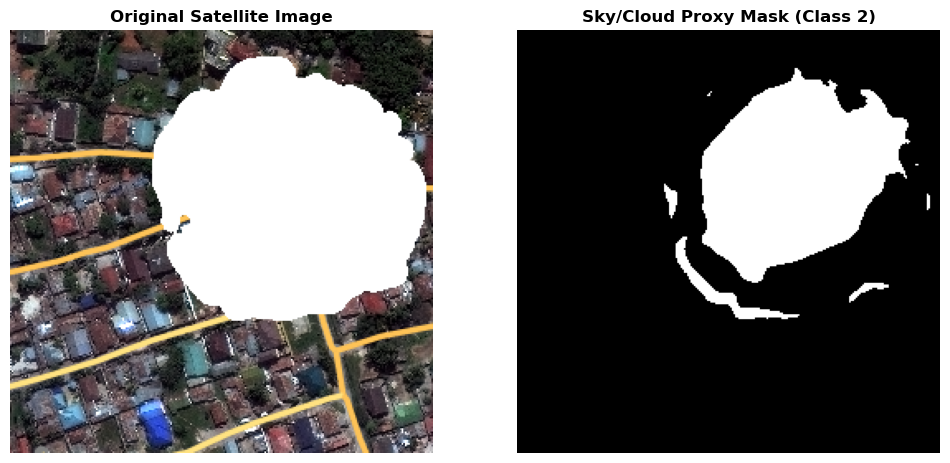

In [16]:
cloud_mask = (pred_seg == CLOUD_MASK_ID).astype(np.uint8)


fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(image)
ax[0].set_title("Original Satellite Image")
ax[0].axis('off')

ax[1].imshow(cloud_mask, cmap='gray')
ax[1].set_title(f"Sky/Cloud Proxy Mask (Class {CLOUD_MASK_ID})")
ax[1].axis('off')

plt.show()